In [232]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, roc_auc_score, roc_curve, auc

In [210]:
ROOT_DIR = os.getcwd()
DATA_DIR = os.path.join(ROOT_DIR, "..", "data")
RESULTS_DIR = os.path.join(ROOT_DIR, "..", "results")
meta = pd.read_csv(os.path.join(DATA_DIR, "participants.tsv"), sep="\t")

In [211]:
meta.head()

,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22


EEGNet AD vs. CN classification

In [57]:
# Load results from EEGNet AD vs CN classification
file_path = "EEGNet_A_C/C_A/all_results.pkl"

with open(os.path.join(RESULTS_DIR, file_path), "rb") as f:
    eegnet_ad = pickle.load(f)

In [58]:
# Check keys in results
eegnet_ad.keys()

dict_keys(['meta_data', 'outer_folds', 'subject_metadata'])

In [79]:
# Check fold metadata
eegnet_ad["meta_data"]

{'model_name': 'EEGNet_A_C',
 'class_names': ['C', 'A'],
 'label_map': {'A': 1, 'C': 0},
 'epoch_duration': 4,
 'sampling_rate': 128,
 'chans': 19,
 'samples': 512}

In [60]:
# Check the number of saved folds
print(len(eegnet_ad["outer_folds"]))

65


In [59]:
# Check keys in outer folds
eegnet_ad["outer_folds"][0].keys()

dict_keys(['outer_fold', 'test_subject_id', 'best_trial_number', 'best_params', 'best_epochs', 'trained_epochs', 'inner_model_filepath', 'val_loss', 'val_accuracy', 'test_accuracy', 'true_labels', 'pred_probs', 'pred_labels'])

In [81]:
# Check fold results
for fold in eegnet_ad["outer_folds"]:
    print(fold["outer_fold"], fold["test_subject_id"], fold["test_accuracy"])

1 sub-001 1.0
2 sub-002 0.25316455696202533
3 sub-003 0.7368421052631579
4 sub-004 1.0
5 sub-005 0.9875311720698254
6 sub-006 0.09841269841269841
7 sub-007 1.0
8 sub-008 0.9746835443037974
9 sub-009 0.40327868852459015
10 sub-010 0.514866979655712
11 sub-011 0.4490861618798956
12 sub-012 0.37727272727272726
13 sub-013 0.9401913875598086
14 sub-014 0.9527896995708155
15 sub-015 0.49443207126948774
16 sub-016 0.9876288659793815
17 sub-017 1.0
18 sub-018 1.0
19 sub-019 0.7467248908296943
20 sub-020 0.9838337182448037
21 sub-021 0.25925925925925924
22 sub-022 0.9951100244498777
23 sub-023 0.9375
24 sub-024 1.0
25 sub-025 0.04105571847507331
26 sub-026 1.0
27 sub-027 1.0
28 sub-028 1.0
29 sub-029 1.0
30 sub-030 1.0
31 sub-031 0.4059233449477352
32 sub-032 0.9445843828715366
33 sub-033 0.9943019943019943
34 sub-034 0.9958592132505176
35 sub-035 1.0
36 sub-036 0.3126491646778043
37 sub-037 0.6640826873385013
38 sub-038 0.7454954954954955
39 sub-039 0.8160377358490566
40 sub-040 0.844074844074

In [83]:
# Check one specific fold 
fold_idx = 0
fold = eegnet_ad["outer_folds"][fold_idx]

y_true = fold["true_labels"]
y_pred = fold["pred_labels"]
y_prob = fold["pred_probs"]

print("True labels:", y_true[:10])
print("Predicted labels:", y_pred[:10])
print("Predicted probabilities:", y_prob[:10])

True labels: [1 1 1 1 1 1 1 1 1 1]
Predicted labels: [1 1 1 1 1 1 1 1 1 1]
Predicted probabilities: [0.6815293  0.6920767  0.69437766 0.6809404  0.718216   0.73593575
 0.71233547 0.72508967 0.7563343  0.7186408 ]


In [212]:
# Append subject metadata to results
eegnet_ad["subject_metadata"] = {}

for fold in eegnet_ad["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        # print(subject_id)
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        eegnet_ad["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

In [99]:
# Check updated metadata
eegnet_ad["subject_metadata"]["sub-001"]

{'gender': 'F', 'age': 57, 'group': 'A'}

In [147]:
# Get test accuracies across folds
test_accuracies = []

for fold in eegnet_ad["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

df_accuracies = pd.DataFrame(test_accuracies)
df_accuracies.head()

,test_subject_id,test_accuracy
0,sub-001,1.000000
1,sub-002,0.253165
2,sub-003,0.736842
3,sub-004,1.000000
4,sub-005,0.987531


In [131]:
print(df_accuracies["test_accuracy"].mean(), df_accuracies["test_accuracy"].std())

0.7068570434091808 0.3162519917755785


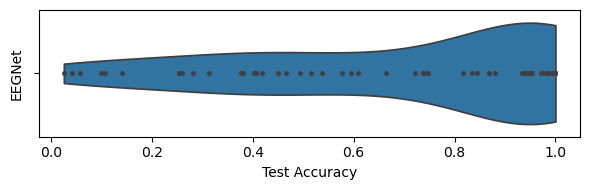

In [ ]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2)) 
sns.violinplot(data=df_accuracies, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("EEGNet")
plt.tight_layout()
plt.savefig("figures/EEGNet_AD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [132]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in eegnet_ad["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [134]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7071552439116339
F1 Score: 0.7416522548889185
Sensitivity: 0.7682237839327546
Specificity: 0.6333666333666333
ROC AUC: 0.8171267521463883
Confusion Matrix:
 [[ 7608  4404]
 [ 3364 11150]]


In [196]:
# Subject-level predictions and true labels
rows = []

for fold in eegnet_ad["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]

    # Majority vote for subject-level prediction
    pred_majority = np.bincount(y_pred).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

df_subjects = pd.DataFrame(rows)

In [197]:
df_subjects.head()

,subject_id,true_label,pred_label
0,sub-001,1,1
1,sub-002,1,0
2,sub-003,1,1
3,sub-004,1,1
4,sub-005,1,1


In [198]:
cm_subjects = confusion_matrix(df_subjects["true_label"], df_subjects["pred_label"])
print("Subject-level Confusion Matrix:\n", cm_subjects)

Subject-level Confusion Matrix:
 [[20  9]
 [10 26]]


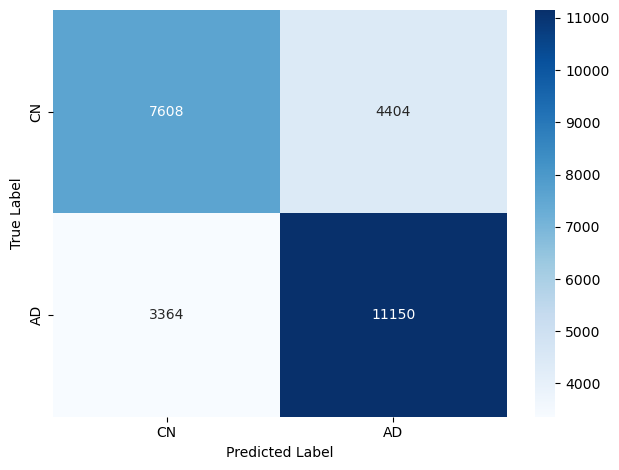

In [ ]:
# Plot sample-level confusion matrix
class_names = ["CN", "AD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/EEGNet_AD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

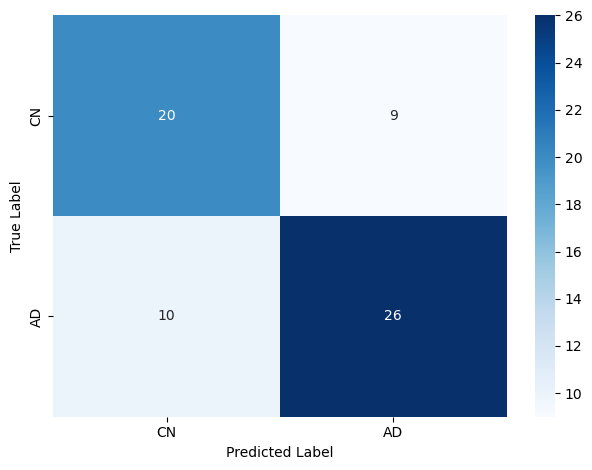

In [202]:
# Plot subject-level confusion matrix
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/EEGNet_AD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

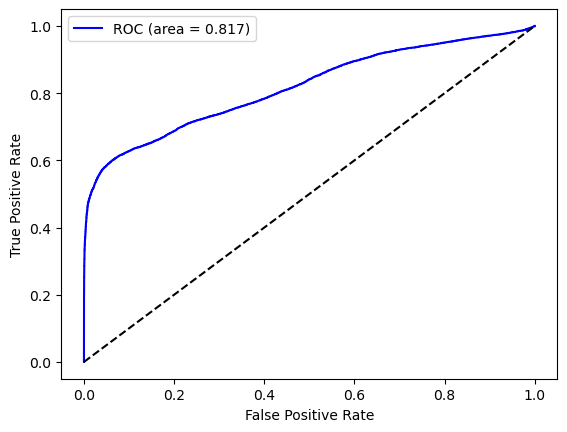

In [182]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.savefig("figures/EEGNet_AD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

EEGNet FTD vs. CN classification

In [203]:
# Load results from EEGNet FTD vs CN classification
with open(os.path.join(RESULTS_DIR, "EEGNet_F_C/C_F/all_results.pkl"), "rb") as f:
    eegnet_ftd = pickle.load(f)

In [204]:
# Check fold results 
for fold in eegnet_ftd["outer_folds"]:
    print(fold["outer_fold"], fold["test_subject_id"], fold["test_accuracy"])

1 sub-037 1.0
2 sub-038 0.6936936936936937
3 sub-039 0.9245283018867925
4 sub-040 0.7858627858627859
5 sub-041 0.9366515837104072
6 sub-042 0.9645833333333333
7 sub-043 0.25181598062953997
8 sub-044 0.9749430523917996
9 sub-045 0.01179245283018868
10 sub-046 0.8613333333333333
11 sub-047 0.9427860696517413
12 sub-048 0.8661257606490872
13 sub-049 1.0
14 sub-050 0.3832923832923833
15 sub-051 0.8933333333333333
16 sub-052 0.6358839050131926
17 sub-053 0.9794344473007712
18 sub-054 0.9496402877697842
19 sub-055 0.874384236453202
20 sub-056 0.9543147208121827
21 sub-057 0.9899244332493703
22 sub-058 0.9787798408488063
23 sub-059 0.04846938775510204
24 sub-060 0.5978552278820375
25 sub-061 0.1775
26 sub-062 0.28348214285714285
27 sub-063 0.6184538653366584
28 sub-064 1.0
29 sub-065 0.5895691609977324
30 sub-066 0.9047619047619048
31 sub-067 0.46875
32 sub-068 0.14385964912280702
33 sub-069 0.9337539432176656
34 sub-070 0.008403361344537815
35 sub-071 0.5357142857142857
36 sub-072 1.0
37 sub

In [205]:
# Check one fold results
fold_idx = 0
fold = eegnet_ftd["outer_folds"][fold_idx]

y_true = fold["true_labels"]
y_pred = fold["pred_labels"]
y_prob = fold["pred_probs"]

print("True labels:", y_true[:10])
print("Predicted labels:", y_pred[:10])
print("Predicted probabilities:", y_prob[:10])

True labels: [0 0 0 0 0 0 0 0 0 0]
Predicted labels: [0 0 0 0 0 0 0 0 0 0]
Predicted probabilities: [0.44469136 0.44542128 0.45801425 0.48206866 0.46989244 0.47374836
 0.45696595 0.44376737 0.44228467 0.47025478]


In [214]:
# Append subject metadata to results
eegnet_ftd["subject_metadata"] = {}

for fold in eegnet_ftd["outer_folds"]:
    for subject_id in np.unique(fold["test_subject_id"]):
        subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
        eegnet_ftd["subject_metadata"][subject_id] = {
            "gender": subject_meta["Gender"],
            "age": subject_meta["Age"],
            "group": subject_meta["Group"]
        }

In [216]:
# Check updated metadata
eegnet_ftd["subject_metadata"]["sub-060"]

{'gender': 'F', 'age': 71, 'group': 'C'}

In [217]:
# Get test accuracies across folds
test_accuracies = []

for fold in eegnet_ftd["outer_folds"]:
    acc = fold["test_accuracy"]
    test_accuracies.append({
        "test_subject_id": fold["test_subject_id"],
        "test_accuracy": acc
    })

df_accuracies = pd.DataFrame(test_accuracies)
df_accuracies.head()

,test_subject_id,test_accuracy
0,sub-037,1.000000
1,sub-038,0.693694
2,sub-039,0.924528
3,sub-040,0.785863
4,sub-041,0.936652


In [218]:
print(df_accuracies["test_accuracy"].mean(), df_accuracies["test_accuracy"].std())

0.6691228535221766 0.35736405613226463


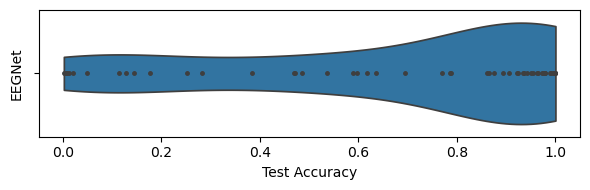

In [219]:
# Violin plot of test accuracies
plt.figure(figsize=(6, 2))
sns.violinplot(data=df_accuracies, x="test_accuracy", inner="point", cut=0)
plt.xlabel("Test Accuracy")
plt.ylabel("EEGNet")
plt.tight_layout()
plt.savefig("figures/EEGNet_FTD_CN_test_accuracies_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [220]:
# Get predictions and true labels across folds
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold in eegnet_ftd["outer_folds"]:
    all_y_true.extend(fold["true_labels"])
    all_y_pred.extend(fold["pred_labels"])
    all_y_prob.extend(fold["pred_probs"])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

In [221]:
# Calculate overall metrics
accuracy = accuracy_score(all_y_true, all_y_pred)
f1_score_value = f1_score(all_y_true, all_y_pred)
sensitivity = recall_score(all_y_true, all_y_pred)
specificity = recall_score(all_y_true, all_y_pred, pos_label=0)
roc_auc = roc_auc_score(all_y_true, all_y_prob)
cm = confusion_matrix(all_y_true, all_y_pred)
print("Accuracy:", accuracy)
print("F1 Score:", f1_score_value)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6754463845319127
F1 Score: 0.5994643291940589
Sensitivity: 0.5959816025175503
Specificity: 0.7301032301032301
ROC AUC: 0.7004532323159773
Confusion Matrix:
 [[8770 3242]
 [3338 4924]]


In [224]:
# Subject-level predictions and true labels
rows = []

for fold in eegnet_ftd["outer_folds"]:
    y_true = fold["true_labels"]
    y_pred = fold["pred_labels"]
    subject_ids = fold["test_subject_id"]

    # Majority vote for subject-level prediction
    pred_majority = np.bincount(y_pred).argmax()
    true_label = y_true

    rows.append({
        "subject_id": subject_ids,
        "true_label": true_label[0],
        "pred_label": pred_majority
    })

df_subjects = pd.DataFrame(rows)
df_subjects.head()

,subject_id,true_label,pred_label
0,sub-037,0,0
1,sub-038,0,0
2,sub-039,0,0
3,sub-040,0,0
4,sub-041,0,0


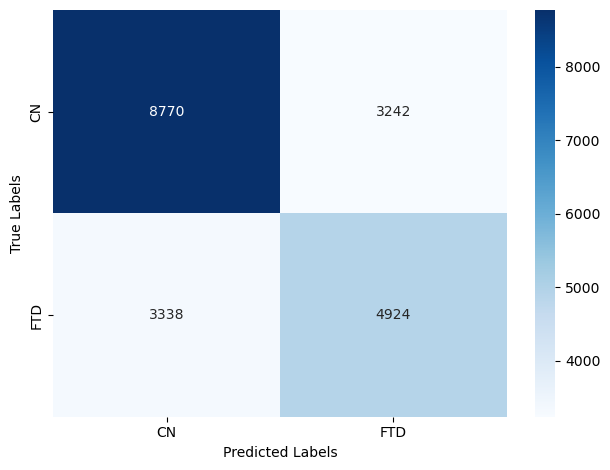

In [228]:
# Plot sample-level confusion matrix
class_names = ["CN", "FTD"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/EEGNet_FTD_CN_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

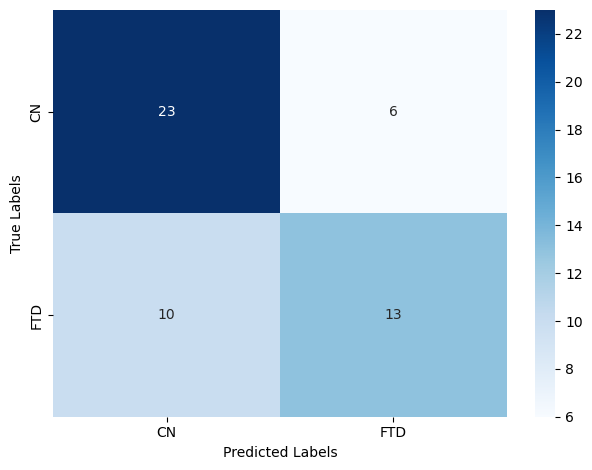

In [229]:
# Plot subject-level confusion matrix
cm_subjects = confusion_matrix(df_subjects["true_label"], df_subjects["pred_label"])
sns.heatmap(cm_subjects, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig("figures/EEGNet_FTD_CN_subject_confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

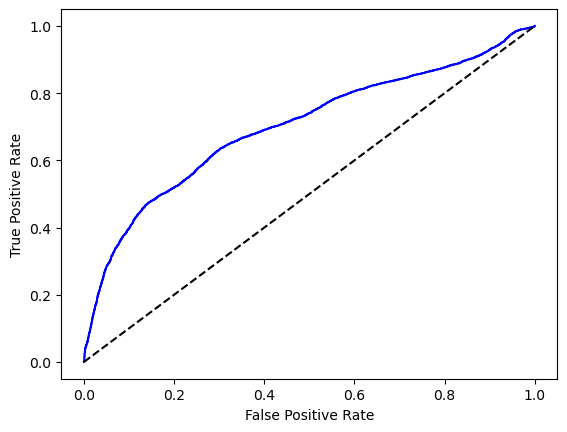

In [230]:
# Plot AUC ROC curve
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
auc_val = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC (area = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig("figures/EEGNet_FTD_CN_ROC_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()